This Notebook show to generate synthetic voltages based on event parameters to calculate stastistics that can be used for optimization

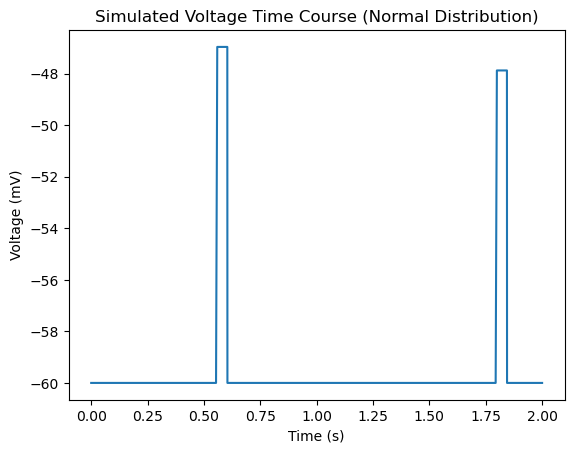

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def generate_time_course(total_time, dt, resting_voltage, 
                         event_freq_params, event_amp_params, event_duration_params, 
                         rise_time=0.005, distribution_mode='normal'):
    """
    Generates a voltage time course with non-overlapping events added to a resting voltage.
    Each event features a linear ramp over 'rise_time' seconds before reaching full amplitude.
    
    Parameters:
      total_time: Total simulation time (seconds).
      dt: Time step (seconds).
      resting_voltage: Baseline voltage.
      event_freq_params: Tuple with (mean, std) for normal mode or (low, high) for uniform mode,
                         representing events per second.
      event_amp_params: Tuple with (mean, std) or (low, high) for event amplitude.
      event_duration_params: Tuple with (mean, std) or (low, high) for event duration (seconds).
      rise_time: Duration (in seconds) over which the event amplitude linearly rises.
      distribution_mode: 'normal' or 'uniform'
      
    Returns:
      t: Time vector.
      voltage: Voltage time course array.
    """
    t = np.arange(0, total_time, dt)
    voltage = np.full_like(t, resting_voltage, dtype=float)
    
    # Determine number of candidate events based on event frequency
    if distribution_mode == 'normal':
        freq_mean, freq_std = event_freq_params
        expected_events = freq_mean * total_time
        n_events = int(max(np.random.normal(expected_events, freq_std * total_time), 0))
    else:
        freq_low, freq_high = event_freq_params
        n_events = int(np.random.uniform(freq_low * total_time, freq_high * total_time))
    
    # Generate candidate event onsets and sort them
    candidate_onsets = np.sort(np.random.uniform(0, total_time, n_events))
    
    last_end_time = -np.inf
    valid_onsets = []
    amplitudes = []
    durations = []
    
    # Accept candidate events only if they do not overlap the previous event.
    for onset in candidate_onsets:
        if distribution_mode == 'normal':
            amp_mean, amp_std = event_amp_params
            dur_mean, dur_std = event_duration_params
            amplitude = np.random.normal(amp_mean, amp_std)
            duration = np.random.normal(dur_mean, dur_std)
        else:
            amp_low, amp_high = event_amp_params
            dur_low, dur_high = event_duration_params
            amplitude = np.random.uniform(amp_low, amp_high)
            duration = np.random.uniform(dur_low, dur_high)
            
        # Ensure the duration is at least one time step
        duration = max(duration, dt)
        
        # Accept event if its onset is after the previous event's end time.
        if onset >= last_end_time:
            valid_onsets.append(onset)
            amplitudes.append(amplitude)
            durations.append(duration)
            last_end_time = onset + duration  # update last event end time
    
    # Add each valid event to the voltage trace with a ramp then plateau
    for onset, amplitude, duration in zip(valid_onsets, amplitudes, durations):
        start_idx = int(onset / dt)
        end_idx = int(min((onset + duration) / dt, len(t)))
        event_steps = end_idx - start_idx
        ramp_steps = int(rise_time / dt)
        
        # If event is shorter than rise_time, ramp through entire event
        if event_steps <= ramp_steps:
            for i in range(event_steps):
                voltage[start_idx + i] += amplitude * (i + 1) / event_steps
        else:
            # Linear ramp phase
            for i in range(ramp_steps):
                voltage[start_idx + i] += amplitude * (i + 1) / ramp_steps
            # Plateau phase
            for i in range(ramp_steps, event_steps):
                voltage[start_idx + i] += amplitude
                
    return t, voltage

# Example usage:
if __name__ == "__main__":
    total_time = 2.0      # seconds
    dt = 0.0001             # seconds
    resting_voltage = -60.0  # mV
    
    # For normal distribution: (mean, std) values
    event_freq_params = (5, 1)          # mean frequency 5 Hz, std 1 Hz
    event_amp_params = (40, 5)          # mean amplitude 20, std 5
    event_duration_params = (0.05, 0.01)  # mean duration 50 ms, std 10 ms

    # For uniform distribution: (mean, std) values
    event_freq_params = (3, 1)          # mean frequency 5 Hz, std 1 Hz
    event_amp_params = (20, 5)          # mean amplitude 20, std 5
    event_duration_params = (.050,.050)#(0.05, 0.01)  # mean duration 50 ms, std 10 ms
    
    # t, voltage = generate_time_course(total_time, dt, resting_voltage, 
    #                                   event_freq_params, event_amp_params, event_duration_params, 
    #                                   distribution_mode='normal')
    
    t, voltage = generate_time_course(total_time, dt, resting_voltage, 
                                    event_freq_params, event_amp_params, event_duration_params, 
                                    distribution_mode='uniform')
    
    plt.plot(t, voltage)
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")
    plt.title("Simulated Voltage Time Course (Normal Distribution)")
    plt.show()


Generate a timecourse using only mean values

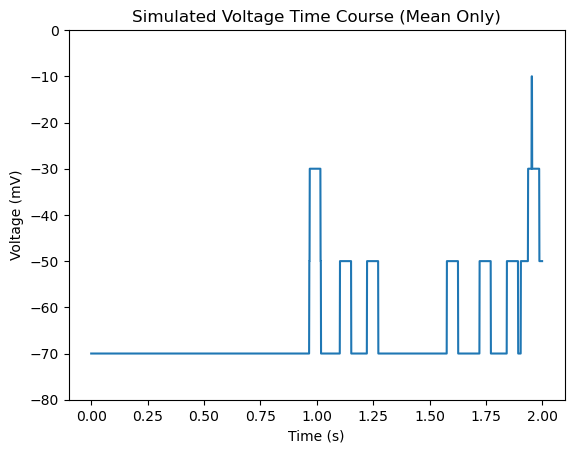

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def generate_time_course_mean(total_time, dt, resting_voltage, 
                                event_frequency_mean, event_amplitude_mean, event_duration_mean):
    """
    Generates a time course using only mean values for events.
    
    Parameters:
      total_time: Total simulation time in seconds.
      dt: Time step in seconds.
      resting_voltage: Baseline voltage.
      event_frequency_mean: Mean event frequency (Hz).
      event_amplitude_mean: Mean event amplitude.
      event_duration_mean: Mean event duration (seconds).
      
    Returns:
      t: Time vector.
      voltage: Voltage time course array.
    """
    t = np.arange(0, total_time, dt)
    voltage = np.full_like(t, resting_voltage, dtype=float)
    
    # Compute the number of events (rounded to nearest integer)
    n_events = int(event_frequency_mean * total_time)
    
    # Randomly assign event onset times uniformly over the time course
    event_onsets = np.sort(np.random.uniform(0, total_time, n_events))
    
    for onset in event_onsets:
        start_idx = int(onset / dt)
        end_idx = int(min((onset + event_duration_mean) / dt, len(t)))
        voltage[start_idx:end_idx] += event_amplitude_mean
        
    return t, voltage

# Example usage:
if __name__ == "__main__":
    total_time = 2#10.0       # seconds
    dt = 0.001              # seconds
    resting_voltage = -70.0  # mV
    event_frequency_mean = 5     # Hz
    event_amplitude_mean = 20    # amplitude units
    event_duration_mean = 0.05   # 50 ms
    
    t, voltage = generate_time_course_mean(total_time, dt, resting_voltage, 
                                           event_frequency_mean, event_amplitude_mean, event_duration_mean)
    
    plt.plot(t, voltage)
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")
    plt.title("Simulated Voltage Time Course (Mean Only)")
    plt.ylim(-80,0)
    plt.show()


Compute statistics

In [17]:
import numpy as np

def compute_statistics(data):
    """
    Computes statistics: mean, standard deviation, variance, and Fano Factor (variance/mean).
    
    Parameters:
      data: A NumPy array of data values (e.g., voltage time course).
      
    Returns:
      data_mean: Mean of the data.
      data_std: Standard deviation of the data.
      data_var: Variance of the data.
      fano_factor: Fano Factor (variance divided by mean); NaN if mean is zero.
    """
    data_mean = np.mean(data)
    data_std = np.std(data)
    data_var = np.var(data)
    fano_factor = data_var / data_mean if data_mean != 0 else np.nan
    return data_mean, data_std, data_var, fano_factor

# Example usage:
if __name__ == "__main__":
    # For demonstration, generate a time course using the function from snippet 1.
    total_time = 10.0
    dt = 0.001
    resting_voltage = -70.0
    event_freq_params = (5, 1)
    event_amp_params = (20, 5)
    event_duration_params = (0.05, 0.01)
    
    t, voltage = generate_time_course(total_time, dt, resting_voltage, 
                                      event_freq_params, event_amp_params, event_duration_params, 
                                      distribution_mode='normal')
    
    mean_val, std_val, var_val, fano = compute_statistics(voltage)
    print("Statistics for the generated voltage time course:")
    print("Mean:", mean_val)
    print("Standard Deviation:", std_val)
    print("Variance:", var_val)
    print("Fano Factor:", fano)


Statistics for the generated voltage time course:
Mean: -64.54212446345527
Standard Deviation: 9.2666399175186
Variance: 85.87061536094913
Fano Factor: -1.330458457554653
